# Exercise 6: Multimodal Music Classification

## Imports

In [86]:
import pathlib

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

## Constants

In [87]:
current_dir = pathlib.Path.cwd()

# Dataset
data_path = current_dir.joinpath("data")

# File extensions
AUDIO_FILE_EXTENSION = ".wav"

## Read and Process Data

In [88]:
guitar1_path = data_path.joinpath("guitar_1" + AUDIO_FILE_EXTENSION)
piano1_path = data_path.joinpath("piano_1" + AUDIO_FILE_EXTENSION)
guitar2_path = data_path.joinpath("guitar_2" + AUDIO_FILE_EXTENSION)
piano2_path = data_path.joinpath("piano_2" + AUDIO_FILE_EXTENSION)

y_g1, sr_g1 = librosa.load(guitar1_path)
y_p1, sr_p1 = librosa.load(piano1_path)

y_g2, sr_g2 = librosa.load(guitar2_path)
y_p2, sr_p2 = librosa.load(piano2_path)

## E1: ADSR-Envelope

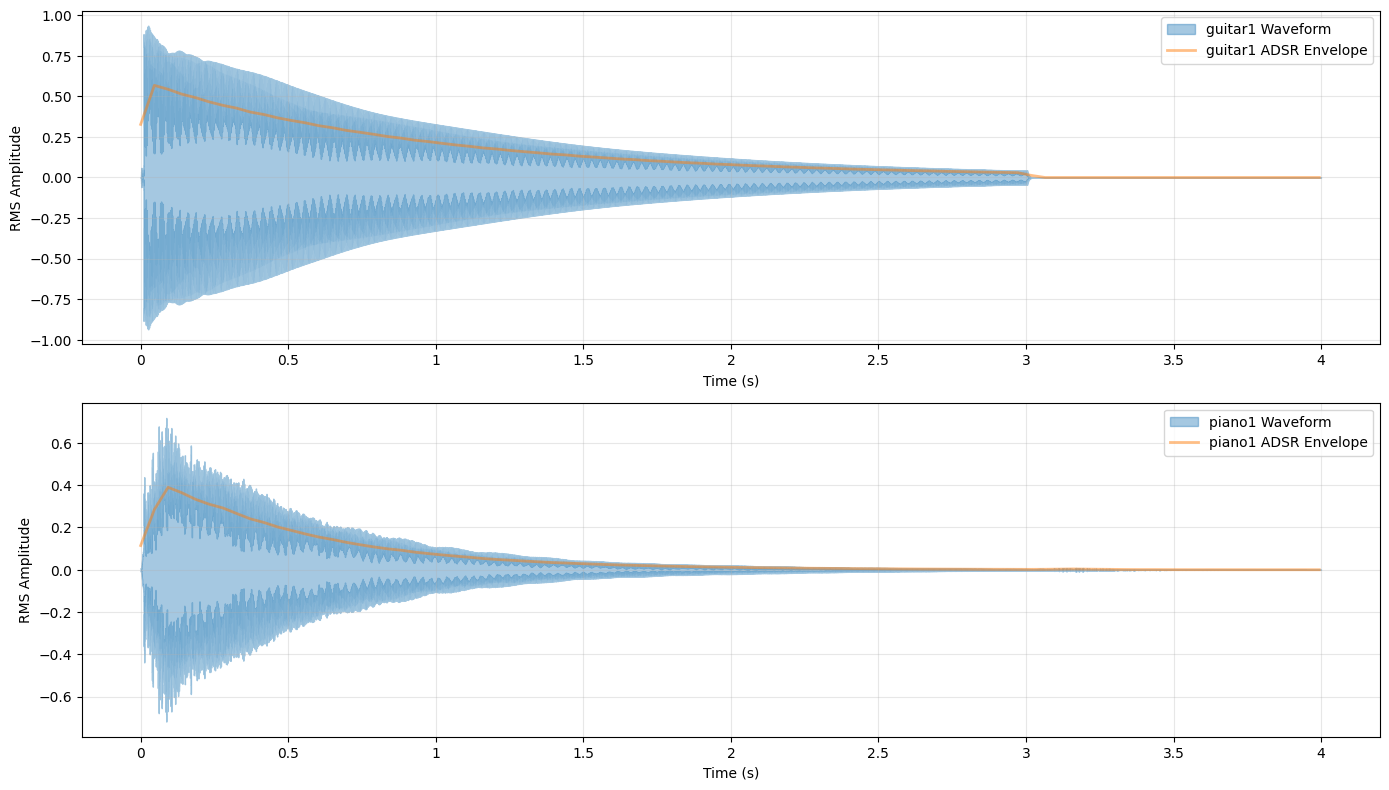

In [89]:
hop_length = 1024
frame_length = 1024

#calculate rms
rms_g1 = librosa.feature.rms(y=y_g1, frame_length=frame_length, hop_length=hop_length)[0]
rms_p1 = librosa.feature.rms(y=y_p1, frame_length=frame_length, hop_length=hop_length)[0]

# get time axis
times_g1 = librosa.times_like(rms_g1, sr=sr_g1, hop_length=hop_length)
times_p1 = librosa.times_like(rms_p1, sr=sr_p1, hop_length=hop_length)

plt.figure(figsize=(14, 8))

#plot adsr for guitar
plt.subplot(2, 1, 1)
librosa.display.waveshow(y_g1, sr=sr_g1, alpha=0.4, label="guitar1 Waveform")
plt.plot(times_g1, rms_g1, linewidth=2, alpha=0.5, label="guitar1 ADSR Envelope")
plt.xlabel("Time (s)")
plt.ylabel("RMS Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

#plot adsr for piano
plt.subplot(2, 1, 2)
librosa.display.waveshow(y_p1, sr=sr_p1, alpha=0.4, label="piano1 Waveform")
plt.plot(times_p1, rms_p1, linewidth=2, alpha=0.5, label="piano1 ADSR Envelope")
plt.xlabel("Time (s)")
plt.ylabel("RMS Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

## E2: Overtone Analysis

In [90]:
f0 = 349.23  # Frequency of F4
n_overtones = 8

harmonic_multipliers = np.arange(n_overtones + 1) + 1
print("Overtones: ", harmonic_multipliers)
harmonic_freqs = f0 * harmonic_multipliers
print("Overtones (Hz): ", harmonic_freqs)


def get_harmonic_amplitudes(y, sr, target_freqs) -> tuple[np.ndarray, np.ndarray]:
    # Get amplitudes
    amplitudes = []

    fft_freqs_for_bins = librosa.fft_frequencies(sr=sr)  # Get frequencies of FFT bins
    s = np.abs(librosa.stft(y))
    s_mean = np.mean(s, axis=1)

    for overtone_freq in target_freqs:
        overtone_idx = np.argmin(np.abs(fft_freqs_for_bins - overtone_freq))
        amplitude = s_mean[overtone_idx]
        amplitudes.append(amplitude)
    linear_amplitudes = np.array(amplitudes)

    # Amplitudes to dB
    amplitudes_db = librosa.amplitude_to_db(linear_amplitudes, ref=np.max)  # ref=1.0

    return linear_amplitudes, amplitudes_db


# analyse all 4 audio samples
l_amps_g1, amps_g1 = get_harmonic_amplitudes(y_g1, sr_g1, harmonic_freqs)
l_amps_p1, amps_p1 = get_harmonic_amplitudes(y_p1, sr_p1, harmonic_freqs)
l_amps_g2, amps_g2 = get_harmonic_amplitudes(y_g2, sr_g2, harmonic_freqs)
l_amps_p2, amps_p2 = get_harmonic_amplitudes(y_p2, sr_p2, harmonic_freqs)

Overtones:  [1 2 3 4 5 6 7 8 9]
Overtones (Hz):  [ 349.23  698.46 1047.69 1396.92 1746.15 2095.38 2444.61 2793.84 3143.07]


In [91]:
# Average harmonic amplitude lists (lengths)
l_amps_g_avg = (l_amps_g1 + l_amps_g2) / 2
l_amps_p_avg = (l_amps_p1 + l_amps_p2) / 2

# Average harmonic amplitude arrays (actual amplitude values)
amps_g_avg = (amps_g1 + amps_g2) / 2
amps_p_avg = (amps_p1 + amps_p2) / 2

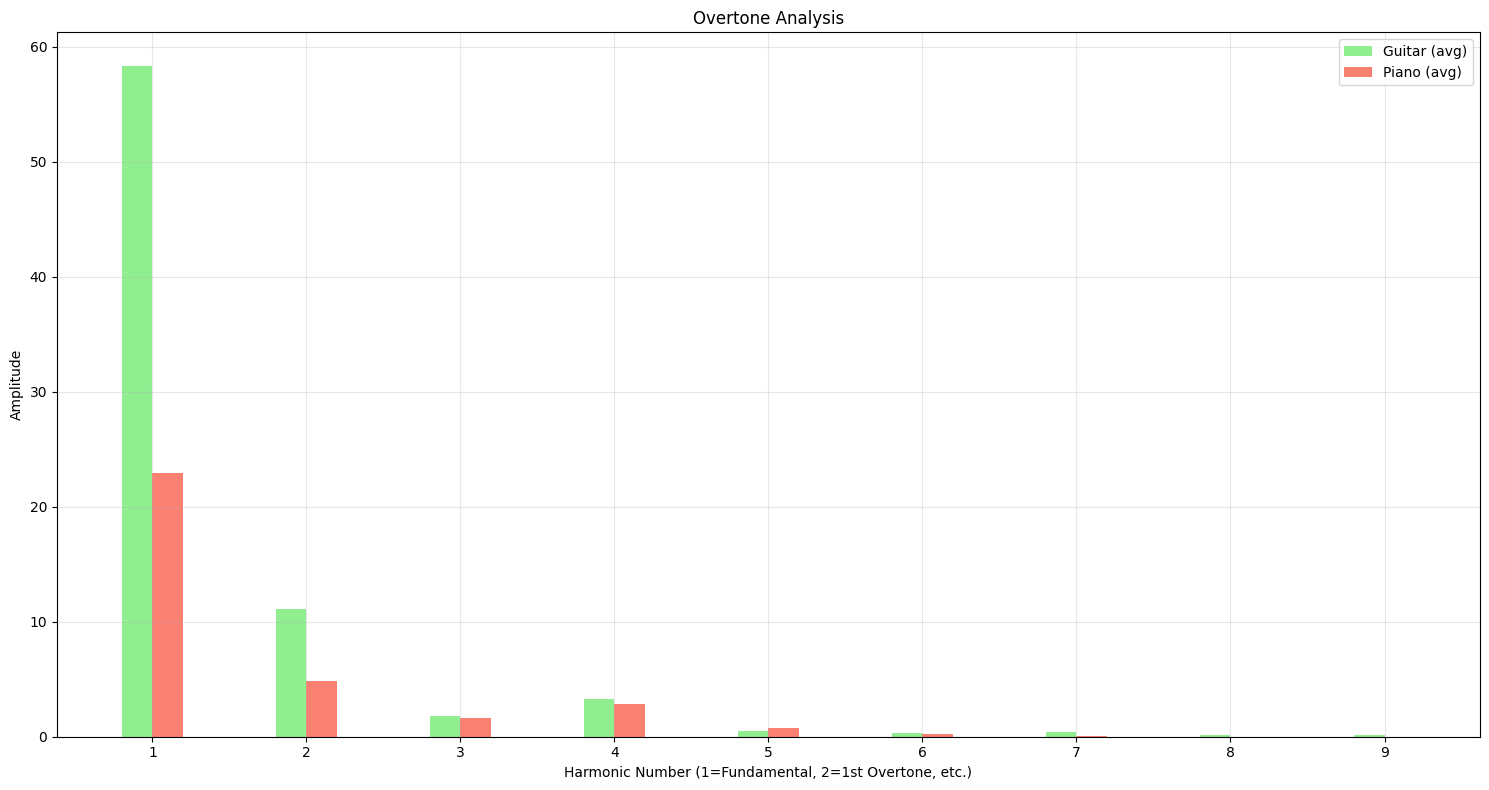

In [92]:
plt.figure(figsize=(15, 8))
x = np.arange(len(harmonic_multipliers))
width = 0.2

plt.bar(x - width / 2, l_amps_g_avg, width, label="Guitar (avg)", color="lightgreen")
plt.bar(x + width / 2, l_amps_p_avg, width, label="Piano (avg)", color="salmon")
plt.title("Overtone Analysis")
plt.xlabel("Harmonic Number (1=Fundamental, 2=1st Overtone, etc.)")
plt.ylabel("Amplitude")
plt.xticks(x, harmonic_multipliers)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

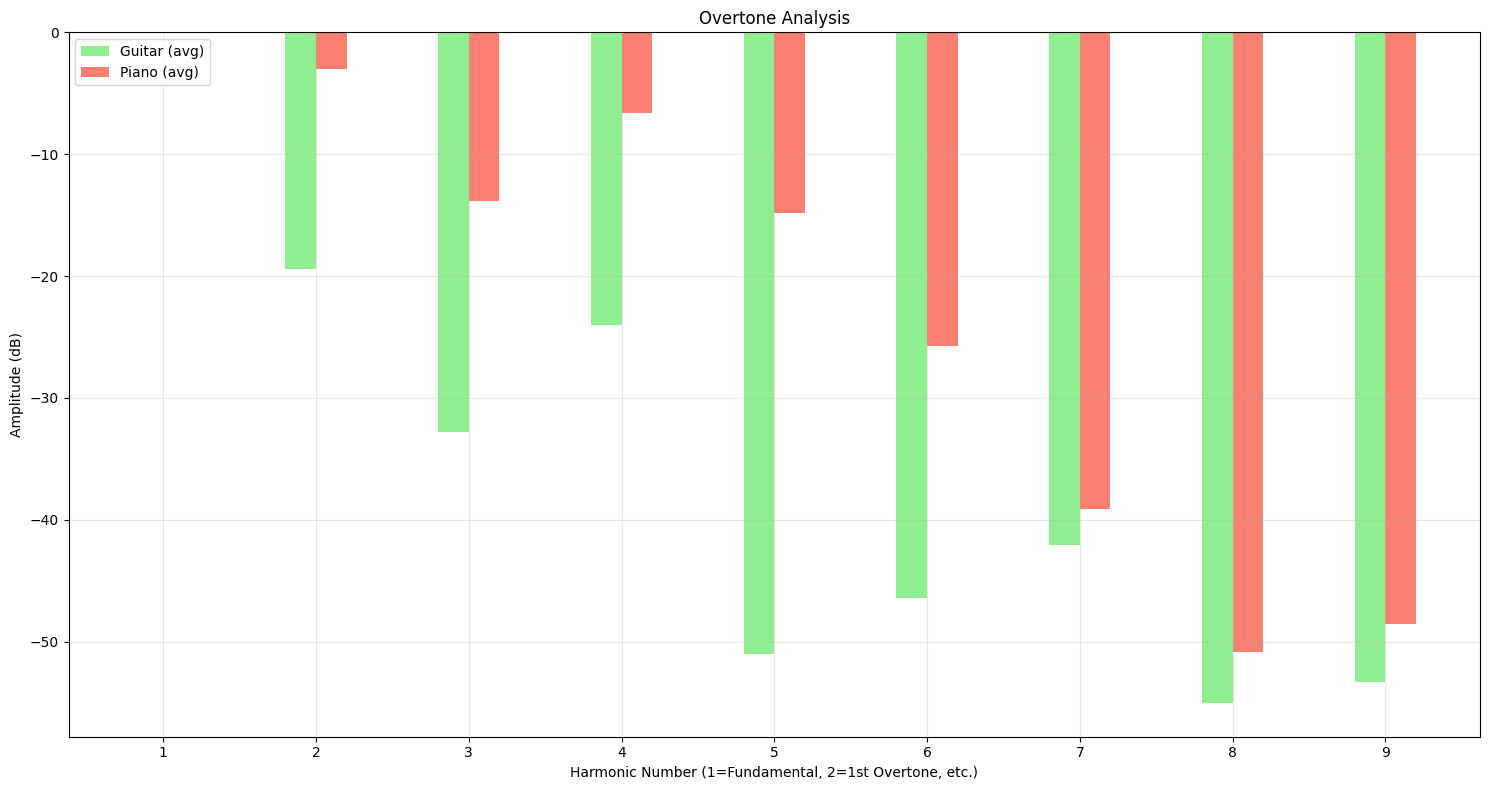

In [93]:
plt.figure(figsize=(15, 8))
x = np.arange(len(harmonic_multipliers))
width = 0.2

plt.bar(x - width / 2, amps_g1, width, label="Guitar (avg)", color="lightgreen")
plt.bar(x + width / 2, amps_p2, width, label="Piano (avg)", color="salmon")
plt.title("Overtone Analysis")
plt.xlabel("Harmonic Number (1=Fundamental, 2=1st Overtone, etc.)")
plt.ylabel("Amplitude (dB)")
plt.xticks(x, harmonic_multipliers)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

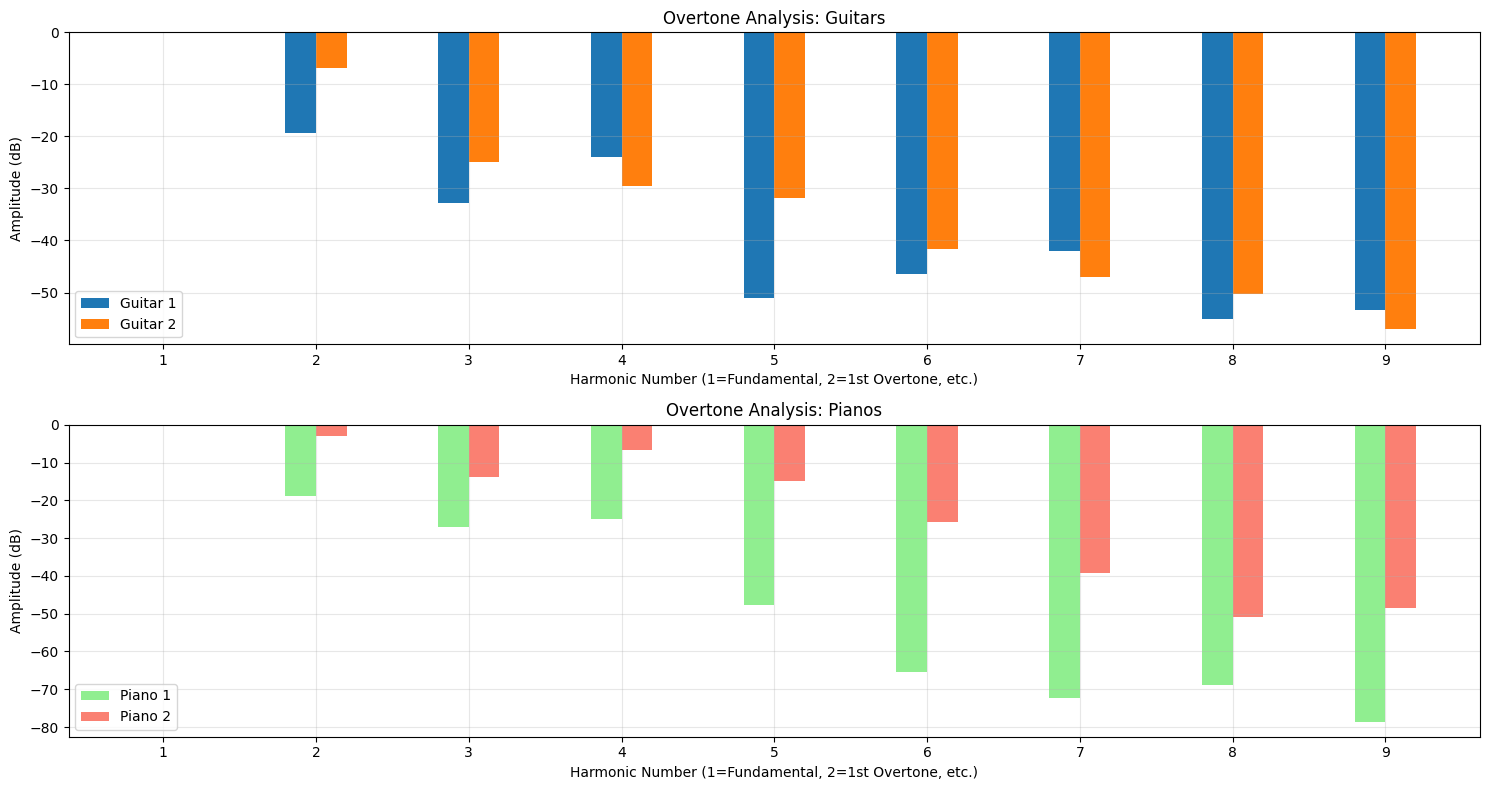

In [94]:
# PLOT DB AMPLITUDES

plt.figure(figsize=(15, 8))
x = np.arange(len(harmonic_multipliers))
width = 0.2

# Guitar Plots
plt.subplot(2, 1, 1)
plt.bar(x - width / 2, amps_g1, width, label="Guitar 1")
plt.bar(x + width / 2, amps_g2, width, label="Guitar 2")
plt.title("Overtone Analysis: Guitars")
plt.xlabel("Harmonic Number (1=Fundamental, 2=1st Overtone, etc.)")
plt.ylabel("Amplitude (dB)")
plt.xticks(x, harmonic_multipliers)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

# Piano Plots
plt.subplot(2, 1, 2)
plt.bar(x - width / 2, amps_p1, width, label="Piano 1", color="lightgreen")
plt.bar(x + width / 2, amps_p2, width, label="Piano 2", color="salmon")
plt.title("Overtone Analysis: Pianos")
plt.xlabel("Harmonic Number (1=Fundamental, 2=1st Overtone, etc.)")
plt.ylabel("Amplitude (dB)")
plt.xticks(x, harmonic_multipliers)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## E3: Noise Analysis

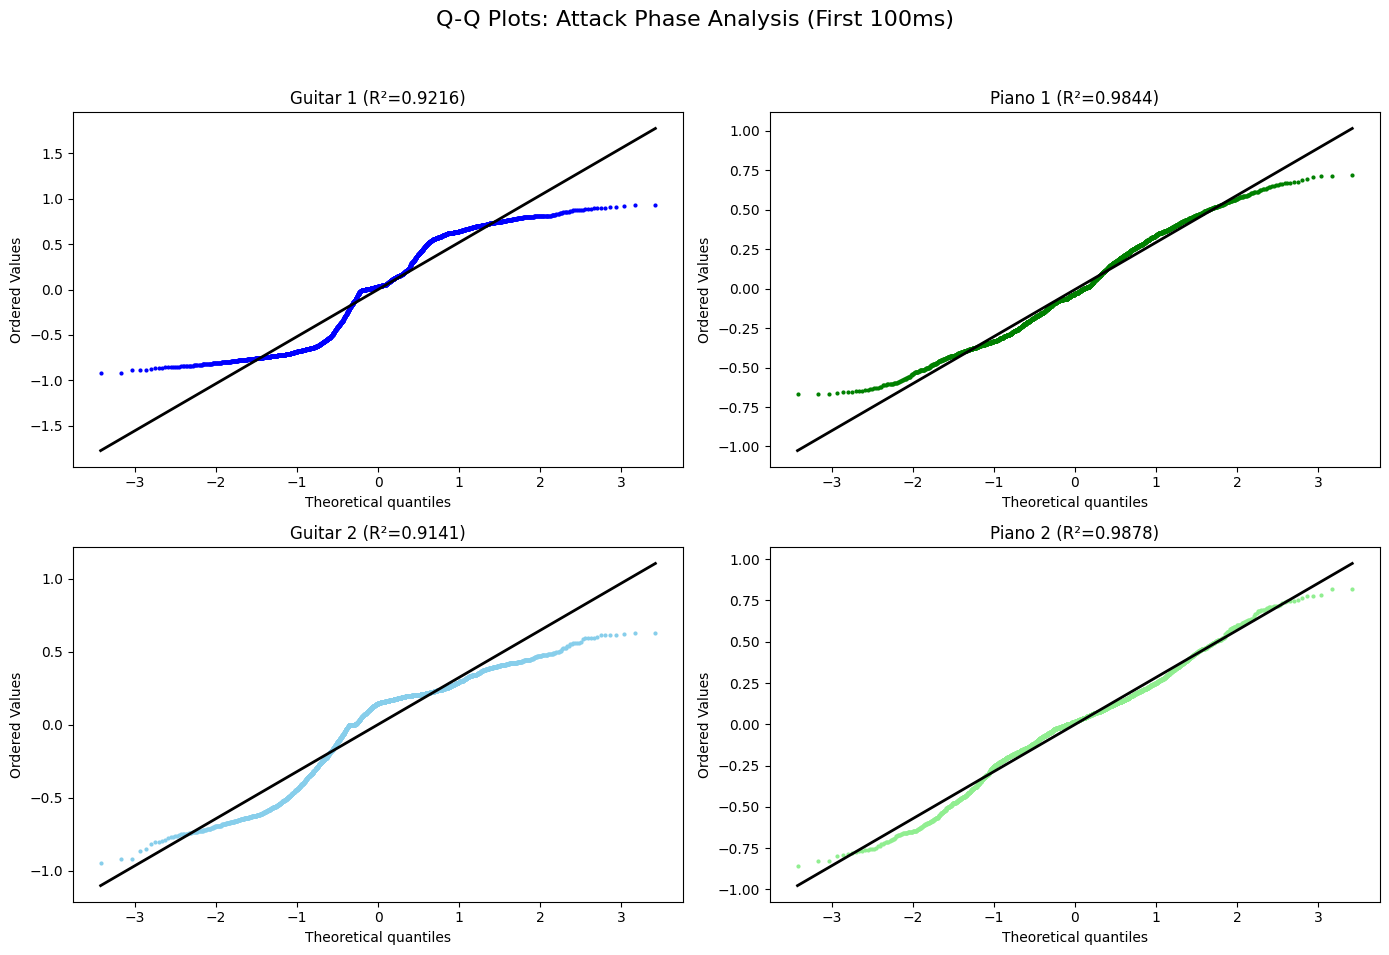

In [95]:
# Define attack duration
attack_duration = 0.1  # 100 ms


# Helper function to slice the audio
def get_attack_segment(y, sr, duration):
    num_samples = int(duration * sr)
    return y[:num_samples]


# Isolate attack phases
attack_g1 = get_attack_segment(y_g1, sr_g1, attack_duration)
attack_p1 = get_attack_segment(y_p1, sr_p1, attack_duration)
attack_g2 = get_attack_segment(y_g2, sr_g2, attack_duration)
attack_p2 = get_attack_segment(y_p2, sr_p2, attack_duration)

# Setup plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Q-Q Plots: Attack Phase Analysis (First 100ms)", fontsize=16)


# Function to plot probplot
def plot_qq(data, ax, title, color):
    # probplot compares data to a normal distribution by default
    _, (slope, intercept, r) = stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f"{title} (R²={r ** 2:.4f})")
    ax.get_lines()[0].set_color(color)
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('black')  # The regression line
    ax.get_lines()[1].set_linewidth(2)


# Generate plots
plot_qq(attack_g1, axes[0, 0], "Guitar 1", "blue")
plot_qq(attack_p1, axes[0, 1], "Piano 1", "green")
plot_qq(attack_g2, axes[1, 0], "Guitar 2", "skyblue")
plot_qq(attack_p2, axes[1, 1], "Piano 2", "lightgreen")

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()